In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("house_price_prediction_dataset.csv")

# First 5 rows
df.head()

,property_id,city,property_type,bedrooms,bathrooms,square_feet,lot_size_sqft,year_built,garage_spaces,furnished,property_condition,distance_to_city_center_km,crime_rate_index,nearby_school_rating,swimming_pool,parking_spaces,days_on_market,house_price
0,PROP00001,Houston,Condo,4,3,1770,2786,2023,1,Yes,Excellent,0.8,5.0,5.9,Yes,1,35.0,736000.0
1,PROP00002,Austin,Condo,4,3,1552,4369,1980,2,Yes,Good,18.8,7.0,7.3,No,3,14.0,669200.0
2,PROP00003,San Diego,Single Family,3,4,1268,4607,1958,0,Yes,Good,12.6,1.1,4.6,No,0,8.0,771800.0
3,PROP00004,Philadelphia,Single Family,4,4,1536,6759,2022,0,Yes,Fair,8.7,1.8,7.0,No,0,12.0,646000.0
4,PROP00005,Los Angeles,Condo,4,3,1169,4664,1997,0,Yes,Good,11.6,1.0,6.3,No,0,13.0,997000.0


In [3]:
#check rows and columns
df.shape

(1500, 18)

In [4]:
#Column names
df.columns

Index(['property_id', 'city', 'property_type', 'bedrooms', 'bathrooms',
       'square_feet', 'lot_size_sqft', 'year_built', 'garage_spaces',
       'furnished', 'property_condition', 'distance_to_city_center_km',
       'crime_rate_index', 'nearby_school_rating', 'swimming_pool',
       'parking_spaces', 'days_on_market', 'house_price'],
      dtype='object')

In [5]:
#dataset values(numerical and categorical)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
property_id                   1500 non-null object
city                          1500 non-null object
property_type                 1500 non-null object
bedrooms                      1500 non-null int64
bathrooms                     1500 non-null int64
square_feet                   1500 non-null int64
lot_size_sqft                 1500 non-null int64
year_built                    1500 non-null int64
garage_spaces                 1500 non-null int64
furnished                     1500 non-null object
property_condition            1500 non-null object
distance_to_city_center_km    1500 non-null float64
crime_rate_index              1472 non-null float64
nearby_school_rating          1483 non-null float64
swimming_pool                 1500 non-null object
parking_spaces                1500 non-null int64
days_on_market                1485 non-null float64
house_price                  

In [6]:
#to check missing values
df.isnull().sum()

property_id                    0
city                           0
property_type                  0
bedrooms                       0
bathrooms                      0
square_feet                    0
lot_size_sqft                  0
year_built                     0
garage_spaces                  0
furnished                      0
property_condition             0
distance_to_city_center_km     0
crime_rate_index              28
nearby_school_rating          17
swimming_pool                  0
parking_spaces                 0
days_on_market                15
house_price                    0
dtype: int64

In [7]:
#Find duplicates
df.duplicated().sum()

0

In [8]:
df = df.drop_duplicates()

In [9]:
#remove duplicates ,Handling missing values
df['crime_rate_index'].fillna(df['crime_rate_index'].median(), inplace=True)

df['nearby_school_rating'].fillna(df['nearby_school_rating'].median(), inplace=True)

df['days_on_market'].fillna(df['days_on_market'].median(), inplace=True)

In [10]:
#dataset
df.describe()

,bedrooms,bathrooms,square_feet,lot_size_sqft,year_built,garage_spaces,distance_to_city_center_km,crime_rate_index,nearby_school_rating,parking_spaces,days_on_market,house_price
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03
mean,3.300667,2.976667,1382.754667,4844.785333,1986.978000,1.553333,12.638133,2.860867,6.474467,1.940000,35.765333,9.031373e+05
std,1.168122,1.213715,553.183564,2609.499406,21.819324,0.845951,11.590887,1.584867,1.744625,0.976235,36.818954,5.150169e+05
min,1.000000,1.000000,500.000000,1000.000000,1950.000000,0.000000,0.500000,0.100000,1.000000,0.000000,1.000000,6.070000e+04
25%,3.000000,2.000000,980.750000,2868.000000,1967.000000,1.000000,3.975000,1.600000,5.300000,1.000000,10.000000,5.226000e+05
50%,3.000000,3.000000,1349.500000,4358.000000,1987.000000,2.000000,9.000000,2.600000,6.500000,2.000000,25.000000,7.239000e+05
75%,4.000000,4.000000,1731.250000,6374.250000,2006.000000,2.000000,18.100000,3.900000,7.700000,3.000000,49.000000,1.266350e+06
max,6.000000,5.000000,3568.000000,16428.000000,2023.000000,3.000000,55.000000,8.500000,10.000000,4.000000,300.000000,3.484100e+06


In [11]:
#to check whether duplicates are all removed
df.isnull().sum()

property_id                   0
city                          0
property_type                 0
bedrooms                      0
bathrooms                     0
square_feet                   0
lot_size_sqft                 0
year_built                    0
garage_spaces                 0
furnished                     0
property_condition            0
distance_to_city_center_km    0
crime_rate_index              0
nearby_school_rating          0
swimming_pool                 0
parking_spaces                0
days_on_market                0
house_price                   0
dtype: int64

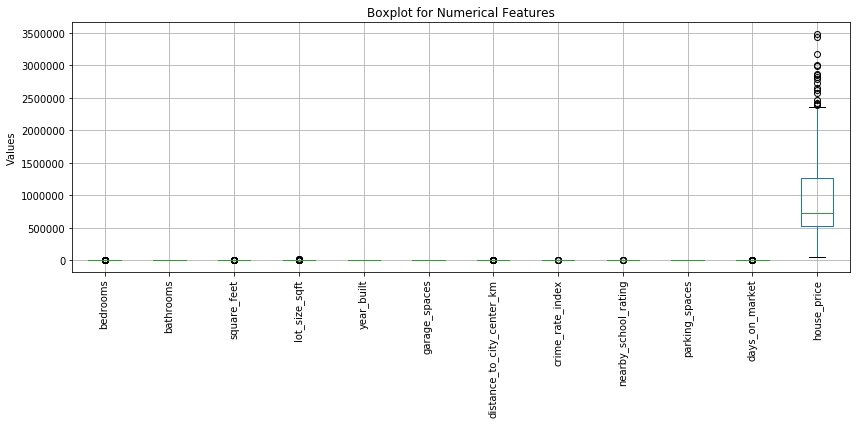

In [15]:
#to check outliers and the graph representation of some outliers in some fields
%matplotlib inline
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(12,6))
df[numeric_columns].boxplot(rot=90)
plt.title("Boxplot for Numerical Features")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [16]:
# Check outliers using IQR with for loop

numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

bedrooms: 145 outliers
bathrooms: 0 outliers
square_feet: 16 outliers
lot_size_sqft: 27 outliers
year_built: 0 outliers
garage_spaces: 0 outliers
distance_to_city_center_km: 62 outliers
crime_rate_index: 4 outliers
nearby_school_rating: 4 outliers
parking_spaces: 0 outliers
days_on_market: 75 outliers
house_price: 17 outliers


In [ ]:
#outlier not removed as they may change the property values or some outliers reason may be due to uniques house and house price